# Milestone 03 — Model Comparison
**Project:** Customer Churn Prediction (Telco) &nbsp;|&nbsp; **Builds on:** Milestones 01–02

**Objective:** train and compare two genuinely different algorithms — **logistic regression** (a linear model) and
**random forest** (a tree-based ensemble) — and explain, from the data itself, why one outperforms (or underperforms) the other.

Both models reuse the same preprocessing pipeline and the same imbalance-handling approach
(`class_weight="balanced"` / `"balanced_subsample"`, following what Milestone 02 found effective for this data), so any difference
in results reflects the **algorithm**, not the feature preparation.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.config import RANDOM_STATE, TEST_SIZE
from src.data_preparation import clean, load_raw, make_xy
from src.evaluation import cross_validate_on_train, evaluate_on, plot_confusion_matrix, plot_roc
from src.preprocessing import build_logistic_class_weighted, build_random_forest_class_weighted

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Setup complete. Random seed:", RANDOM_STATE)

Setup complete. Random seed: 42


## 1. Recap: load, clean, split
Same seed and logic as Milestones 01–02, so this notebook reproduces the exact same train/test rows.

In [2]:
raw = load_raw()
df, cleaning_log = clean(raw)
X, y = make_xy(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape, "| Churn rate (train):", round(y_train.mean(), 3))

Train: (5634, 19) | Test: (1409, 19) | Churn rate (train): 0.265


## 2. The two models

| | Logistic Regression | Random Forest |
| --- | --- | --- |
| **Type** | Linear model | Ensemble of decision trees (bagging) |
| **Decision boundary** | A single straight (hyper)plane in the scaled/encoded feature space | Piecewise, built from many axis-aligned splits combined by voting |
| **Feature interactions** | Not captured unless explicitly added (e.g. interaction terms) | Captured automatically — a tree can split on `Contract` and then again on `tenure` within that branch |
| **Scaling required?** | Yes (already in the shared pipeline) | No, but harmless to include for a fair, identical pipeline |
| **Imbalance handling** | `class_weight="balanced"` | `class_weight="balanced_subsample"` (recomputed per bootstrap sample) |
| **Interpretability** | Coefficients — direct, signed, additive effect | Feature importances — relative, unsigned, no direction |
| **Tuning done here** | None beyond the class weight | `n_estimators=300`, `max_depth=8`, `min_samples_leaf=5` — reasonable defaults, not tuned |

Neither model's hyperparameters were tuned against the test set in this milestone; both use fixed, reasonable settings so the
comparison reflects the algorithms themselves.

In [3]:
logreg = build_logistic_class_weighted(X_train)
rf = build_random_forest_class_weighted(X_train)
models = {"Logistic Regression": logreg, "Random Forest": rf}

## 3. Cross-validation comparison (training set only)

In [4]:
cv_results = {name: cross_validate_on_train(m, X_train, y_train)["mean"] for name, m in models.items()}
cv_table = pd.DataFrame(cv_results).round(3)
cv_table

,Logistic Regression,Random Forest
accuracy,0.748,0.764
precision,0.517,0.539
recall,0.801,0.775
f1,0.628,0.636
roc_auc,0.846,0.848
pr_auc,0.660,0.661


## 4. Final fit and test-set evaluation
Both models are fitted once on the full training set and evaluated once on the held-out test set — the same discipline as the
earlier milestones. Training-set scores are also recorded here (not to select a model, only to check for **overfitting**
afterwards in Section 6).

In [5]:
fitted = {}
train_scores, test_scores, preds = {}, {}, {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    train_scores[name], _, _ = evaluate_on(model, X_train, y_train)
    test_scores[name], y_pred, y_proba = evaluate_on(model, X_test, y_test)
    preds[name] = (y_pred, y_proba)

test_table = pd.DataFrame(test_scores).round(3)
test_table

,Logistic Regression,Random Forest
accuracy,0.738,0.760
precision,0.504,0.533
recall,0.783,0.783
f1,0.614,0.634
roc_auc,0.842,0.842
pr_auc,0.633,0.648


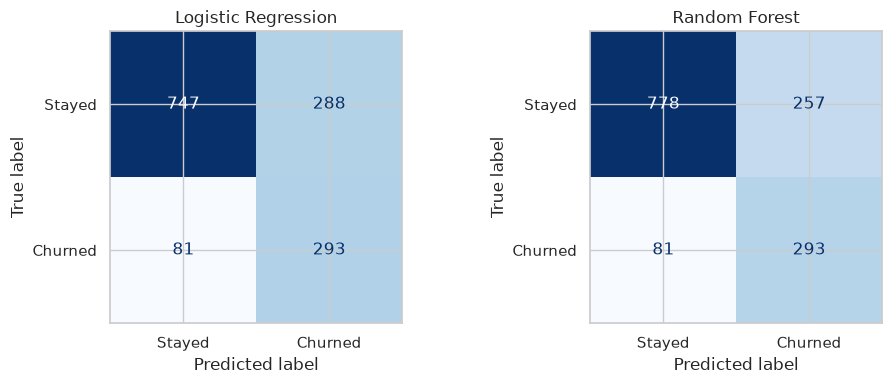

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, fitted.items()):
    y_pred, _ = preds[name]
    from sklearn.metrics import ConfusionMatrixDisplay
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Stayed", "Churned"], cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

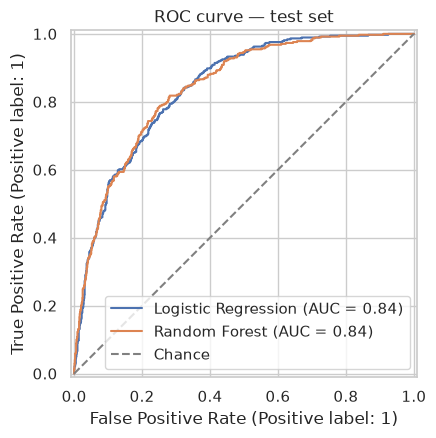

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
from sklearn.metrics import RocCurveDisplay
for name, model in fitted.items():
    _, y_proba = preds[name]
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax.set_title("ROC curve — test set")
ax.legend(loc="lower right")
plt.show()